# Music graph analysis

## Setup

In [1]:
# ────────────────────────────────────────────────────────────────
# Set path
# ────────────────────────────────────────────────────────────────

import sys
import os
from pathlib import Path

# 1) Locate this script (or notebook) directory
try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    # __file__ doesn't exist in notebooks or REPLs
    script_dir = Path.cwd()

# 2) Assume project root is one level up from `python/`
project_root = script_dir.parent

# 3) Sanity check: ensure there's a `data/` folder at the root
if not (project_root / "data").is_dir():
    raise RuntimeError(f"Project root {project_root!r} has no data/ folder.")

# 4) Prepend to sys.path so you can `import` anywhere in Music_Project
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# Import packages
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import wikipediaapi
from concurrent.futures import ProcessPoolExecutor, as_completed
from concurrent.futures import ThreadPoolExecutor
import threading
import time
import ast
from collections import Counter, defaultdict

# Load data
df_orig = pd.read_csv(project_root / "data" / "raw" / "originals.csv")
df_cov = pd.read_csv(project_root / "data" / "raw" / "covers.csv")
df_neo = pd.read_csv(project_root / "data" / "raw" / "neo4j_artists.csv")

## Wikipedia data collection


In [3]:
# Create dataframe containing only artists with wikipedia links
df_neo_artists = df_neo[['artist_id', 'common_name', 'wiki_url']]
df_neo_artists = df_neo_artists[df_neo_artists['wiki_url'].notna() & (df_neo_artists['wiki_url'] != '')]

# Create dictionaries to map artist ids to names and urls
artist_urls = dict(zip(df_neo_artists['artist_id'], df_neo_artists['wiki_url']))
url_to_artist = {url: id for id, url in artist_urls.items()}
id_to_name = dict(zip(df_neo['artist_id'], df_neo['common_name']))

In [4]:
# Load Wikipedia API
wiki = wikipediaapi.Wikipedia(user_agent="MusicGraphExample (research@example.com)", language="en")

def get_all_links_for_artists(artist_urls, max_workers=10, batch_print=200):
    """
    Run the Wikipedia API calls once, store all linked URLs per artist.
    Returns: dict mapping artist_id -> set of linked artist URLs
    """
    artist_ids = list(artist_urls.keys())
    total = len(artist_ids)
    lock = threading.Lock()
    progress = {'count': 0}
    all_links = {}

    def worker(artist):
        url = artist_urls[artist]
        tries = 3
        for attempt in range(tries):
            try:
                if '/wiki/' not in url:
                    return artist, set()
                page_title = url.split('/wiki/')[-1]
                page = wiki.page(page_title)
                if not page.exists():
                    return artist, set()
                links = page.links.keys()
                full_urls = {f"https://en.wikipedia.org/wiki/{link}" for link in links}
                return artist, full_urls
            except Exception as e:
                if attempt == tries - 1:
                    print(f"Exception in get_page_links for url {url}: {e}")
                    return artist, set()
                else:
                    time.sleep(2 ** attempt)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(worker, artist_ids)

        for artist, linked_urls in results:
            with lock:
                progress['count'] += 1
                if progress['count'] % batch_print == 0 or progress['count'] == total:
                    print(f"Processed {progress['count']} / {total} artists...")
            all_links[artist] = linked_urls

    return all_links

# Get linked urls for all artists
all_links = get_all_links_for_artists(artist_urls)

Processed 200 / 5828 artists...
Processed 400 / 5828 artists...
Processed 600 / 5828 artists...
Processed 800 / 5828 artists...
Processed 1000 / 5828 artists...
Processed 1200 / 5828 artists...
Processed 1400 / 5828 artists...
Processed 1600 / 5828 artists...
Processed 1800 / 5828 artists...
Processed 2000 / 5828 artists...
Processed 2200 / 5828 artists...
Processed 2400 / 5828 artists...
Processed 2600 / 5828 artists...
Processed 2800 / 5828 artists...
Processed 3000 / 5828 artists...
Processed 3200 / 5828 artists...
Processed 3400 / 5828 artists...
Processed 3600 / 5828 artists...
Processed 3800 / 5828 artists...
Processed 4000 / 5828 artists...
Processed 4200 / 5828 artists...
Processed 4400 / 5828 artists...
Processed 4600 / 5828 artists...
Processed 4800 / 5828 artists...
Processed 5000 / 5828 artists...
Processed 5200 / 5828 artists...
Processed 5400 / 5828 artists...
Processed 5600 / 5828 artists...
Processed 5800 / 5828 artists...
Processed 5828 / 5828 artists...


## Graph creation


### Wikipedia relations

In [5]:
def build_graph_from_links(all_links, url_to_artist, id_to_name):
    """
    Build the graph using pre-fetched all_links dictionary.

    Directed graph
    Nodes: artists with urls
    Edges artist -> mentioned_artist: mentioned_artist was mentioned in artist's wiki page
    """
    G = nx.DiGraph()
    for artist in all_links.keys():
        G.add_node(artist, name=id_to_name.get(artist, "Unknown"))

    for artist, linked_urls in all_links.items():
        for linked_url in linked_urls:
            if linked_url in url_to_artist and linked_url != artist_urls[artist]:
                mentioned_artist = url_to_artist[linked_url]
                G.add_edge(artist, mentioned_artist, relation={'MENTIONS'})

    print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

# Build graph with wikipedia mentions
G = build_graph_from_links(all_links, url_to_artist, id_to_name)

Graph built with 5828 nodes and 10085 edges.


In [6]:
# Basic stats
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Count mentions: who is mentioned most (incoming edges)
mention_count = Counter(v for _, v in G.edges())
top10 = mention_count.most_common(10)

print("Top-10 most-mentioned artists:")
for name, cnt in top10:
    print(f"{G.nodes[name]['name']}: mentioned by {cnt} pages")

Nodes: 5828
Edges: 10085
Top-10 most-mentioned artists:
Adele: mentioned by 389 pages
Beyoncé: mentioned by 373 pages
U2: mentioned by 360 pages
Eminem: mentioned by 316 pages
Madonna: mentioned by 312 pages
Metallica: mentioned by 255 pages
Aerosmith: mentioned by 242 pages
Coldplay: mentioned by 241 pages
Rihanna: mentioned by 240 pages
Bono: mentioned by 225 pages


### Genre property

In [7]:
# 1) Read in your full artist CSV
path = project_root/"data/scraping/genre/artist_genres.csv"
df_genres = pd.read_csv(path)

# 2) Collect the genre columns into a list, dropping empties/NaNs
genre_cols = [f"genre_{i}" for i in range(1, 14)]
df_genres["genres"] = (
    df_genres[genre_cols]
      .apply(lambda row: [g for g in row if pd.notna(g) and g != ""], axis=1)
)

# 3) Index by the same artist key you use in G (artist_id)
df_genres.set_index("artist_id", inplace=True)

# 4) Attach the genres list as a property to each node in G
for artist in G.nodes():
    if artist in df_genres.index:
        G.nodes[artist]["genres"] = df_genres.at[artist, "genres"]
    else:
        G.nodes[artist]["genres"] = []

# 5) Verify on a few nodes
for artist in list(G.nodes())[:5]:
    print(G.nodes[artist]['name'], "→", G.nodes[artist]["genres"])

Van Morrison → ['r&b & soul', 'world', 'rock', 'electronic', 'folk', 'blues / country', 'jazz', 'other', 'pop']
Dinah Washington → ['jazz', 'blues / country', 'electronic', 'other', 'pop']
Aretha Franklin → ['r&b & soul', 'electronic', 'other', 'jazz', 'pop']
Marie Fredriksson → ['rock']
The Beach Boys → ['rock', 'pop']


In [8]:
def flatten_genres(genres):
    """Flatten nested lists in genres into a single-level list of strings."""
    flat = []
    if genres is None:
        return flat
    for g in genres:
        if isinstance(g, list):
            flat.extend(g)
        else:
            flat.append(g)
    # Optionally convert everything to str (if needed)
    flat = [str(x) for x in flat]
    return flat

for node in G.nodes():
    genres = G.nodes[node].get('genres', [])
    G.nodes[node]['genres'] = flatten_genres(genres)


# Verify on a few nodes
for artist in list(G.nodes())[:5]:
    print(G.nodes[artist]['name'], "→", G.nodes[artist]["genres"])

Van Morrison → ['r&b & soul', 'world', 'rock', 'electronic', 'folk', 'blues / country', 'jazz', 'other', 'pop']
Dinah Washington → ['jazz', 'blues / country', 'electronic', 'other', 'pop']
Aretha Franklin → ['r&b & soul', 'electronic', 'other', 'jazz', 'pop']
Marie Fredriksson → ['rock']
The Beach Boys → ['rock', 'pop']


next code cell can probably be deleted

In [9]:
rock_edges_both = [
    (u, v)
    for u, v in G.edges()
    if 'rock' in G.nodes[u].get('genres', []) and
       'rock' in G.nodes[v].get('genres', [])
]

rock_nodes_both = {n for edge in rock_edges_both for n in edge}

print(f"Number of nodes in 'rock ↔ rock' edges: {len(rock_nodes_both)}")
print("Nodes:", rock_nodes_both)

Number of nodes in 'rock ↔ rock' edges: 1333
Nodes: {24576, 6, 65543, 11, 14, 16, 17, 16401, 20, 28, 24608, 33, 24609, 35, 24611, 8229, 41, 42, 45, 48, 49, 32819, 52, 53, 54, 57, 57409, 69, 73, 75, 76, 32847, 8273, 8274, 41044, 85, 88, 90, 24666, 96, 100, 101, 32870, 103, 65639, 105, 24683, 116, 119, 128, 134, 8337, 150, 152, 155, 156, 24733, 158, 162, 167, 169, 32937, 171, 16569, 187, 191, 193, 198, 201, 204, 205, 211, 212, 73941, 214, 223, 41184, 41185, 227, 229, 230, 233, 33002, 240, 49400, 41208, 8445, 98562, 259, 260, 269, 281, 282, 24857, 8476, 24858, 65818, 291, 293, 294, 297, 298, 8489, 8491, 8492, 8493, 303, 306, 307, 24885, 98628, 326, 334, 65872, 347, 354, 361, 372, 374, 375, 49527, 377, 378, 8569, 382, 387, 391, 394, 8587, 402, 49565, 16802, 33187, 423, 8636, 33216, 451, 41415, 457, 41424, 16852, 8661, 33240, 41443, 484, 8690, 512, 74241, 90624, 515, 524, 526, 527, 74258, 533, 535, 25112, 537, 25113, 543, 545, 556, 557, 559, 25147, 8764, 8765, 584, 33358, 33359, 597, 600, 6

### Cover relations

In [10]:
# Merge on org_perf_id column in df_cov and perf_id in df_orig, keep only cov_art_id and org_art_id 
# Not merging on song title because songs can have the same names
df_merged = pd.merge(
    df_cov[['org_perf_id', 'cov_art_id']],
    df_orig[['perf_id', 'org_art_id']],
    left_on='org_perf_id',
    right_on='perf_id',
    how='inner'
)[['cov_art_id', 'org_art_id']]

print(df_merged.head())
print(df_merged.shape)

  cov_art_id org_art_id
0      [879]        [1]
1   [5, 237]     [5483]
2        [7]        [6]
3       [10]        [8]
4        [9]        [8]
(367622, 2)


In [11]:
# Step 1: Parse stringified lists if needed
def parse_list(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return [val]
    return val

df_merged['cov_art_id'] = df_merged['cov_art_id'].apply(parse_list)
df_merged['org_art_id'] = df_merged['org_art_id'].apply(parse_list)

# Step 2: Explode both columns
df_exploded = df_merged.explode('cov_art_id').explode('org_art_id').reset_index(drop=True)
print(df_exploded)

       cov_art_id org_art_id
0             879          1
1               5       5483
2             237       5483
3               7          6
4              10          8
...           ...        ...
482896      64925      11276
482897      35611      17062
482898      14339       2437
482899      14339      69125
482900        894       1389

[482901 rows x 2 columns]


In [12]:
edge_count = 0
for _, row in df_merged.iterrows():
    covering_artists = row['cov_art_id']
    original_artists = row['org_art_id']

    # Create edges for every pair (covering -> original)
    for cov_id in covering_artists:
        for org_id in original_artists:
            if cov_id != org_id: # avoid self-loop #and cov_id in G and org_id in G:
                
                # Ensure nodes exist with name attributes
                if cov_id not in G:
                    G.add_node(cov_id, name=id_to_name.get(cov_id, "Unknown"))
                if org_id not in G:
                    G.add_node(org_id, name=id_to_name.get(org_id, "Unknown"))

                # If edge exists, add weight to it 
                if G.has_edge(cov_id, org_id):
                    edge_data = G[cov_id][org_id]
                    edge_data.setdefault('relation', set()).add('COVERED')
                    edge_data['weight'] = edge_data.get('weight', 0) + 1

                # If edge does not exist yet, create edge
                else:
                    G.add_edge(cov_id, org_id, relation={'COVERED'}, weight=1)
                edge_count += 1

In [13]:
# Check if weights are added correctly 
u, v, data = max(G.edges(data=True), key=lambda x: x[2].get('weight', 0))
print(f"Edge with highest weight: {u} → {v}")
print("  Names:", G.nodes[u].get('name', 'Unknown'), "→", G.nodes[v].get('name', 'Unknown'))
print("  Relation:", data.get('relation'))
print("  Weight:", data.get('weight'))

Edge with highest weight: 97325 → 41
  Names: The Coverbeats → The Beatles
  Relation: {'COVERED'}
  Weight: 135


In [14]:
# Basic stats
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Count how many times each artist is covered
cover_count = Counter()

for u, v, data in G.edges(data=True):
    if 'COVERED' in data.get('relation', []):
        cover_count[v] += 1  # v = original artist who was covered

# Get top 10 most covered artists
top_10_covered = cover_count.most_common(10)

# Create the DataFrame
covered_top_10 = pd.DataFrame(
    [(artist, G.nodes[artist]['name'], count) for artist, count in top_10_covered],
    columns=['artist_id', 'artist_name', 'cover_count']
)

covered_top_10

Nodes: 65833
Edges: 414105


,artist_id,artist_name,cover_count
0,41,The Beatles,4448
1,4305,Duke Ellington,2450
2,243,Bing Crosby,2413
3,158,Bob Dylan,1908
4,2232,Fred Astaire,1841
5,319,Frank Sinatra,1654
6,2223,Abbie Mitchell,1590
7,1424,Judy Garland,1550
8,5773,Joseph Mohr,1437
9,5774,Franz Gruber,1437


### Sub-graph creation (cover network vs. wiki network)

In [15]:
# Create covered-only subgraph (with weights)
edges_covered = [(u, v) for u, v, d in G.edges(data=True) if 'COVERED' in d.get('relation', set())]
G_covered = G.edge_subgraph(edges_covered).copy()

# Basic stats
print("Nodes:", G_covered.number_of_nodes())
print("Edges:", G_covered.number_of_edges())

Nodes: 64361
Edges: 404317


In [16]:
# Create mentioned-only subgraph (no weights)
edges_mentions = [(u, v) for u, v, d in G.edges(data=True) if 'MENTIONS' in d.get('relation', set())]
G_mentions = G.edge_subgraph(edges_mentions).copy()

# Basic stats
print("Nodes:", G_mentions.number_of_nodes())
print("Edges:", G_mentions.number_of_edges())

Nodes: 2809
Edges: 10085


## Network description

### Total network

In [17]:
def compute_graph_metrics(G):
    """
    Compute basic graph metrics for a directed or undirected NetworkX graph.
    Uses largest weakly connected component for shortest path calculation.
    """

    # Basic stats
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)

    # Components (weakly connected components for directed graph)
    num_components = nx.number_weakly_connected_components(G)

    # Average shortest path length (largest weakly connected component)
    largest_cc = max(nx.weakly_connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    try:
        avg_shortest_path = nx.average_shortest_path_length(G_sub)
    except:
        avg_shortest_path = "N/A (graph not connected)"

    # Create DataFrame
    metrics = {
        "Metric": [
            "Number of vertices (artists)",
            "Number of edges (song covers)",
            "Number of components",
            "Average shortest path length",
            "Density"
        ],
        "Value": [
            num_nodes,
            num_edges,
            num_components,
            avg_shortest_path,
            density
        ]
    }

    return pd.DataFrame(metrics)

In [18]:
# Description of total network
total_metrics_df = compute_graph_metrics(G)
total_metrics_df

,Metric,Value
0,Number of vertices (artists),65833
1,Number of edges (song covers),414105
2,Number of components,1116
3,Average shortest path length,N/A (graph not connected)
4,Density,0.000096


### Cover network

In [19]:
# Description of cover subgraph
cover_metrics_df = compute_graph_metrics(G_covered)
cover_metrics_df

,Metric,Value
0,Number of vertices (artists),64361
1,Number of edges (song covers),404317
2,Number of components,189
3,Average shortest path length,N/A (graph not connected)
4,Density,0.000098


### Wiki relation network

In [20]:
# Description of wiki subgraph
wiki_metrics_df = compute_graph_metrics(G_mentions)
wiki_metrics_df

,Metric,Value
0,Number of vertices (artists),2809
1,Number of edges (song covers),10085
2,Number of components,12
3,Average shortest path length,N/A (graph not connected)
4,Density,0.001279


## Centrality metrics

### Centrality metrics on cover network

In [21]:
def top_metric_df(metric_scores, graph, score_name, top_n=10):
    """
    Create a DataFrame of the top N nodes for a given metric.

    Parameters
    ----------
    metric_scores : dict
        Dictionary mapping node IDs to metric scores.
    graph : networkx.Graph
        The graph containing the nodes and their attributes.
    score_name : str
        The name of the metric column in the output DataFrame.
    top_n : int, optional
        Number of top nodes to select (default is 10).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: artist_id, artist_name, <score_name>.
    """
    top_nodes = sorted(metric_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame({
        'artist_id': [node for node, _ in top_nodes],
        'artist_name': [graph.nodes[node].get('name', 'Unknown') for node, _ in top_nodes],
        score_name: [score for _, score in top_nodes]
    })

In [22]:
# In-degree centrality
in_deg_cov_scores = nx.in_degree_centrality(G_covered)
in_deg_cov_df = top_metric_df(in_deg_cov_scores, G_covered, 'in_degree_centrality')
in_deg_cov_df 

,artist_id,artist_name,in_degree_centrality
0,41,The Beatles,0.069111
1,4305,Duke Ellington,0.038067
2,243,Bing Crosby,0.037492
3,158,Bob Dylan,0.029646
4,2232,Fred Astaire,0.028605
5,319,Frank Sinatra,0.025699
6,2223,Abbie Mitchell,0.024705
7,1424,Judy Garland,0.024083
8,5773,Joseph Mohr,0.022328
9,5774,Franz Gruber,0.022328


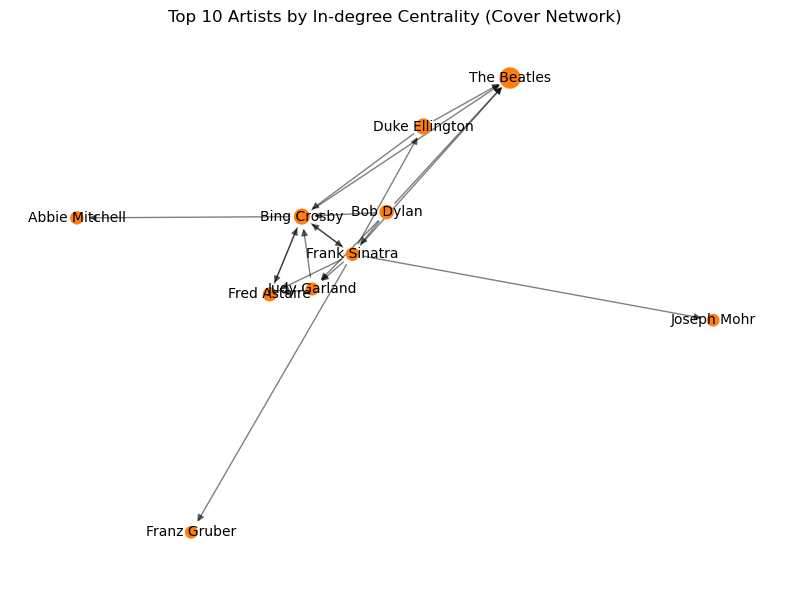

In [23]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the cover network

# Get top 10 artist IDs by in-degree centrality
top_nodes = in_deg_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (optional, for visual effect)
sizes = [in_deg_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [24]:
# PageRank (weighted)
pagerank_cov_scores = nx.pagerank(G_covered, alpha=0.85, weight='weight')
pagerank_cov_df = top_metric_df(pagerank_cov_scores, G_covered, 'pagerank_score')
pagerank_cov_df

,artist_id,artist_name,pagerank_score
0,41,The Beatles,0.012941
1,158,Bob Dylan,0.005808
2,243,Bing Crosby,0.003622
3,616,Depeche Mode,0.003433
4,327,Chuck Berry,0.003406
5,4305,Duke Ellington,0.003387
6,206,The Rolling Stones,0.003340
7,26565,Prince's Band,0.003082
8,90,The Velvet Underground,0.002862
9,1886,Hank Williams,0.002777


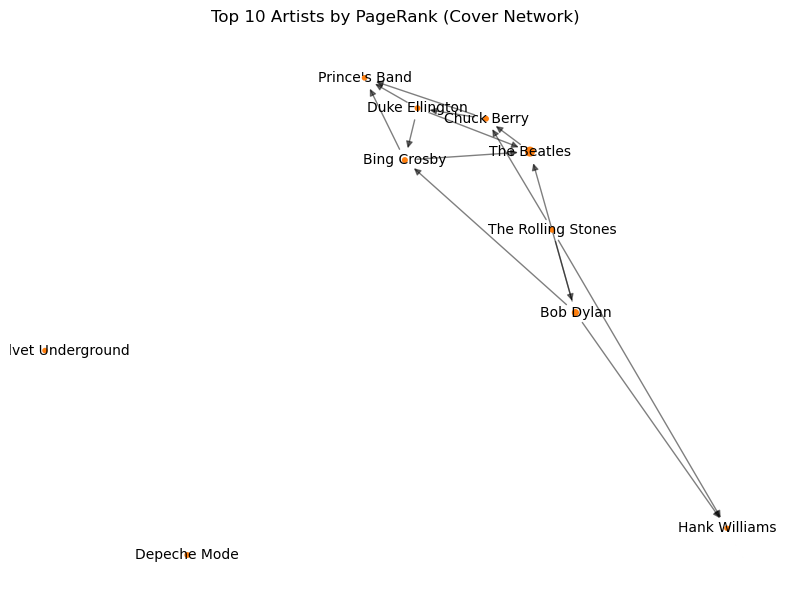

In [25]:
# Visualize only the top 10 PageRank (weighted) nodes and their edges in the cover network

# Get top 10 artist IDs by PageRank
top_nodes = pagerank_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by PageRank score (for visual effect)
sizes = [pagerank_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by PageRank (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [30]:
# Betweenness centrality
betweenness_cov_scores = nx.betweenness_centrality(G_covered, k=100, seed=13)
betweenness_cov_df = top_metric_df(betweenness_cov_scores, G_covered, 'betweenness_centrality')
betweenness_cov_df

,artist_id,artist_name,betweenness_centrality
0,41,The Beatles,0.009123
1,754,Ray Charles,0.005202
2,243,Bing Crosby,0.005127
3,2307,Barbra Streisand,0.004889
4,158,Bob Dylan,0.004317
5,194,David Bowie,0.004298
6,319,Frank Sinatra,0.004014
7,1085,Percy Faith,0.003786
8,103,Elvis Presley,0.003764
9,665,Johnny Cash,0.003725


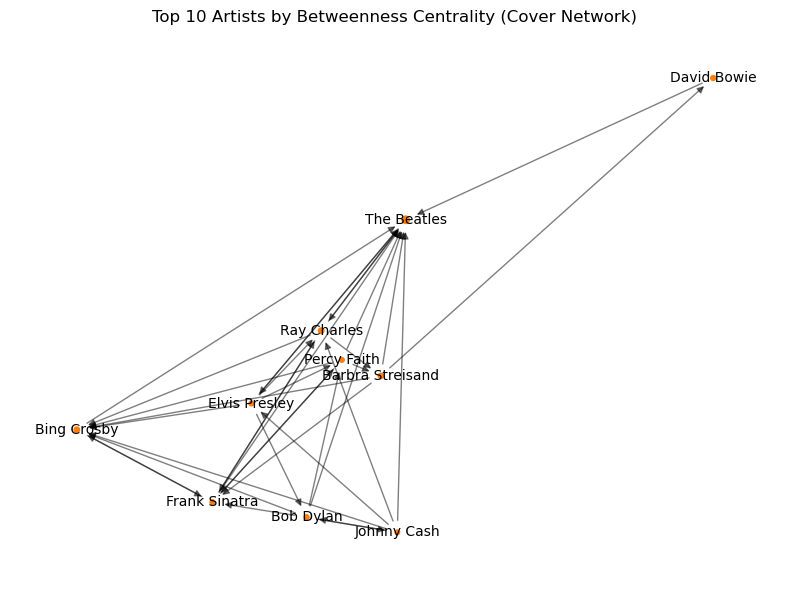

In [27]:
# Visualize only the top 10 Betweenness Centrality nodes and their edges in the cover network


# Get top 10 artist IDs by betweenness centrality
top_nodes = betweenness_cov_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_covered.subgraph(top_nodes).copy()

# Node colors: all orange
node_colors = ["#ff7f0e"] * len(G_top10.nodes())

# Node sizes: scale by betweenness centrality (for visual effect)
sizes = [betweenness_cov_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by Betweenness Centrality (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

##### Layout algorithm: The spring_layout tries to minimize edge crossings and node overlap, but with only a few edges among the top 10, nodes with fewer direct connections will be pushed to the edge.
##### High betweenness in the full network does not guarantee a central position in a subgraph of only the top 10 nodes. The visualization reflects direct connections among those top 10, not their role in the entire network.

### Centrality metrics on wiki network

In [31]:
# In-degree centrality
in_deg_ment_scores = nx.in_degree_centrality(G_mentions)
in_deg_ment_df = top_metric_df(in_deg_ment_scores, G_mentions, 'in_degree_centrality')
in_deg_ment_df

,artist_id,artist_name,in_degree_centrality
0,30607,Adele,0.138533
1,8358,Beyoncé,0.132835
2,297,U2,0.128205
3,224,Eminem,0.112536
4,84,Madonna,0.111111
5,211,Metallica,0.090812
6,223,Aerosmith,0.086182
7,10590,Coldplay,0.085826
8,19179,Rihanna,0.085470
9,1060,Bono,0.080128


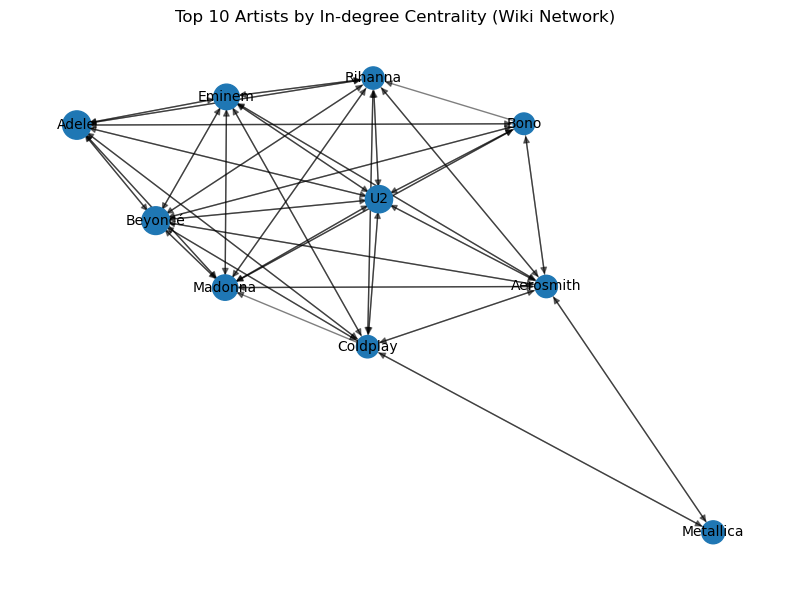

In [32]:
# Visualize only the top 10 in-degree centrality nodes and their edges in the wiki network

# Get top 10 artist IDs by in-degree centrality
top_nodes = in_deg_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by in-degree centrality (for visual effect)
sizes = [in_deg_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by In-degree Centrality (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [33]:
# PageRank
pagerank_ment_scores = nx.pagerank(G_mentions, alpha=0.85)  # no weights
pagerank_ment_df = top_metric_df(pagerank_ment_scores, G_mentions, 'pagerank_score')
pagerank_ment_df 

,artist_id,artist_name,pagerank_score
0,297,U2,0.027058
1,84,Madonna,0.026053
2,224,Eminem,0.025629
3,8358,Beyoncé,0.025492
4,10590,Coldplay,0.023830
5,223,Aerosmith,0.023416
6,211,Metallica,0.023045
7,30607,Adele,0.021258
8,19179,Rihanna,0.021251
9,248,Jay-Z,0.020713


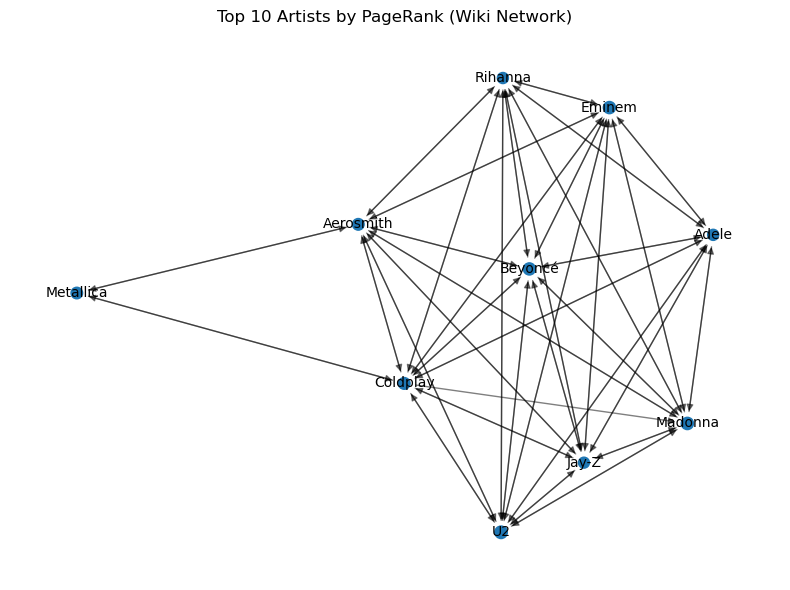

In [34]:
# Visualize only the top 10 PageRank nodes and their edges in the wiki network

# Get top 10 artist IDs by PageRank
top_nodes = pagerank_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by PageRank score (for visual effect)
sizes = [pagerank_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by PageRank (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [35]:
# Betweenness centrality
betweenness_ment_scores = nx.betweenness_centrality(G_mentions, k=100, seed=13)
betweenness_ment_df = top_metric_df(betweenness_ment_scores, G_mentions, 'betweenness_centrality')
betweenness_ment_df

,artist_id,artist_name,betweenness_centrality
0,297,U2,0.007342
1,211,Metallica,0.007298
2,14508,Korn,0.007111
3,84,Madonna,0.006713
4,119,ABBA,0.006615
5,224,Eminem,0.005714
6,8358,Beyoncé,0.005667
7,10590,Coldplay,0.005662
8,223,Aerosmith,0.004601
9,13053,Björk,0.004275


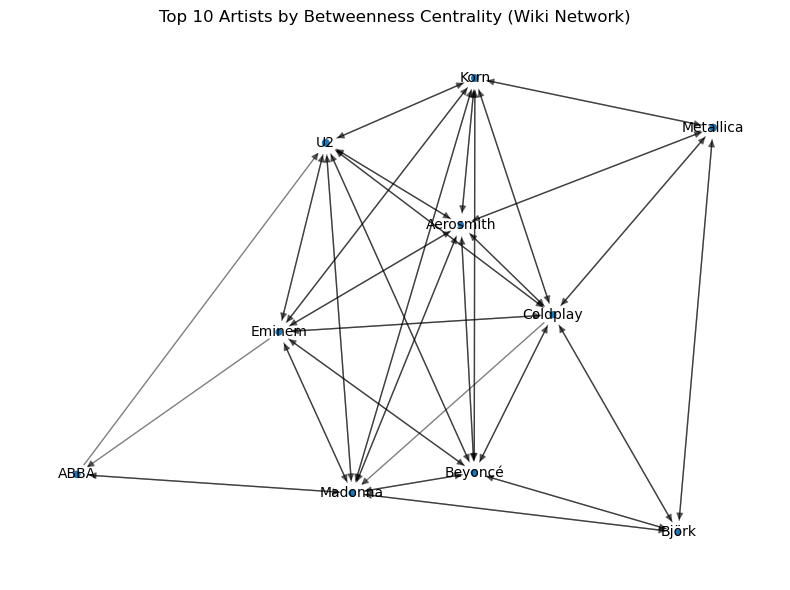

In [36]:
# Visualize only the top 10 Betweenness Centrality nodes and their edges in the wiki network
# Get top 10 artist IDs by betweenness centrality
top_nodes = betweenness_ment_df['artist_id'].tolist()

# Create a subgraph with only the top 10 nodes and edges between them
G_top10 = G_mentions.subgraph(top_nodes).copy()

# Node colors: all blue
node_colors = ["#1f77b4"] * len(G_top10.nodes())

# Node sizes: scale by betweenness centrality (for visual effect)
sizes = [betweenness_ment_scores[n] * 3000 for n in G_top10.nodes()]

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top10, seed=42, k=0.5)

nx.draw_networkx_edges(G_top10, pos, alpha=0.5)
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=sizes)
nx.draw_networkx_labels(
    G_top10, pos,
    labels={n: G_mentions.nodes[n]['name'] for n in G_top10.nodes()},
    font_size=10,
    font_color='black'
)

plt.title("Top 10 Artists by Betweenness Centrality (Wiki Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

### Genre-specific centrality metrics - in progress


In [37]:
# Central helper used across genre analyses (genre impact, cross-PR, etc.)

def genres_similar(genres1, genres2, threshold=0.5):
    """Return True if genre lists are similar under a guarded overlap rule.

    Rule:
    - overlap_ratio = |A ∩ B| / max(|A|, |B|)
    - If max(|A|, |B|) >= 3, also require at least 2 shared tags (small guard for long lists).
    """
    def _clean(gen_list):
        if not gen_list:
            return set()
        out = set()
        for g in gen_list:
            if g is None:
                continue
            s = str(g).strip().casefold()
            if not s:
                continue
            out.add(s)
        return out

    set1, set2 = _clean(genres1), _clean(genres2)
    if not set1 or not set2:
        return False

    overlap = len(set1 & set2)
    max_len = max(len(set1), len(set2))

    # Small guard for long lists: need at least 2 shared tags when either side has >= 3
    min_common = 2 if max_len >= 3 else 1

    overlap_ratio = overlap / max_len
    return (overlap >= min_common) and (overlap_ratio >= threshold)

# Global similarity threshold used throughout (tune here if needed)
_similarity_threshold = 0.5

#### Pagerank on cross-genre only subgraph

In [38]:
# We compute PageRank on the cross-genre-only subgraph 
# and compare it directly with full PageRank.

# Use the full, weighted PageRank computed earlier for G_covered
PR_full = pagerank_cov_scores  # from In[19]

# Build a cross-genre-only subgraph with the same nodes but only cross-genre edges
G_cross = nx.DiGraph()
for n in G_covered.nodes():
    G_cross.add_node(n, **G_covered.nodes[n])

for u, v, d in G_covered.edges(data=True):
    gen_u = G_covered.nodes[u].get('genres', [])
    gen_v = G_covered.nodes[v].get('genres', [])
    if gen_u and gen_v and not genres_similar(gen_u, gen_v, threshold=_similarity_threshold):
        G_cross.add_edge(u, v, weight=d.get('weight', 1))

if G_cross.number_of_edges() > 0:
    pagerank_cross_scores = nx.pagerank(G_cross, alpha=0.85, weight='weight')
else:
    pagerank_cross_scores = {}

# Share: how much of a node's PageRank comes from cross-genre structure
# (simple ratio PR_cross / PR_full; avoid tiny denominators)
min_pr_full_for_share = 1e-6
pagerank_cross_share = {
    n: (pagerank_cross_scores.get(n, 0.0) / PR_full[n])
    for n in PR_full.keys() if PR_full[n] >= min_pr_full_for_share
}

# Note: ratio can exceed 1 because PR_cross and PR_full are normalized on different graphs.
# Display top rankings
_topn = 10
print("\nCross-genre PageRank (edge-filter) — top absolute:")
print(top_metric_df(pagerank_cross_scores, G_covered, 'cross_pagerank').head(_topn))

print("\nCross-genre PageRank ratio (PR_cross / PR_full) — top:")
print(top_metric_df(pagerank_cross_share, G_covered, 'cross_pagerank_share').head(_topn))


# Cross-genre PR (absolute): pagerank_cross_scores[n] 
# --> How central is this artist within the cross-genre subnetwork?
# --> Highlights the heavyweights inside the cross-genre web (big cross-genre hubs).
# --> we can focus only on absolute i think

# Cross-genre PR ratio: pagerank_cross_share[n] = PR_cross[n] / PR_full[n] (with a tiny denominator guard)
# --> How much more (or less) of their centrality comes from cross ties vs the whole graph?
# --> Surfaces artists disproportionately central because of cross-genre ties (can be >1 since each PR is normalized on a different graph).


Cross-genre PageRank (edge-filter) — top absolute:
   artist_id     artist_name  cross_pagerank
0         41     The Beatles        0.002017
1        158       Bob Dylan        0.001988
2        243     Bing Crosby        0.001232
3        319   Frank Sinatra        0.000923
4        103   Elvis Presley        0.000883
5       1886   Hank Williams        0.000772
6       1000  Little Richard        0.000596
7       1424    Judy Garland        0.000526
8        754     Ray Charles        0.000501
9        331     Marvin Gaye        0.000446

Cross-genre PageRank ratio (PR_cross / PR_full) — top:
   artist_id        artist_name  cross_pagerank_share
0      46411        A.R. Rahman              7.106499
1       4308       Oscar Levant              6.192037
2       6105      Dave Lindholm              5.907464
3      16069      William Orbit              5.770898
4      73154         Charli XCX              4.976122
5      53492           Flo Rida              4.809828
6       1420       

#### The visualizations needs to be updated (?)
i have left this section of code untouched

In [39]:
# Visualize top 10 cross-genre in-degree (absolute) in the cover network

# --- Absolute cross-genre in-degree ---
top_nodes_abs = top_cross_in_degree_df['artist_id'].tolist()
G_top10_abs = G_covered.subgraph(top_nodes_abs).copy()
node_colors_abs = ["#2ca02c"] * len(G_top10_abs.nodes())
sizes_abs = [cross_genre_in_degree[n] * 300 for n in G_top10_abs.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_abs = nx.spring_layout(G_top10_abs, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_abs, pos_abs, alpha=0.5)
nx.draw_networkx_nodes(G_top10_abs, pos_abs, node_color=node_colors_abs, node_size=sizes_abs)
nx.draw_networkx_labels(
    G_top10_abs, pos_abs,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_abs.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Cross-Genre In-degree (Absolute, Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Normalized cross-genre in-degree ---
top_nodes_norm = top_norm_cross_in_degree_df['artist_id'].tolist()
G_top10_norm = G_covered.subgraph(top_nodes_norm).copy()
node_colors_norm = ["#d62728"] * len(G_top10_norm.nodes())
sizes_norm = [normalized_cross_in_degree[n] * 3000 for n in G_top10_norm.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_norm = nx.spring_layout(G_top10_norm, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_norm, pos_norm, alpha=0.5)
nx.draw_networkx_nodes(G_top10_norm, pos_norm, node_color=node_colors_norm, node_size=sizes_norm)
nx.draw_networkx_labels(
    G_top10_norm, pos_norm,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_norm.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Normalized Cross-Genre In-degree (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

NameError: name 'top_cross_in_degree_df' is not defined

### The absolue network looks so ugly because our nodes are scaled (node size is proportional to the cross-genre covers) what we are basically seeing now are nodes (Green nodes, "#2ca02c" is green )

#### Participation Coefficient
measures how diversely an artist is covered across genre groups—i.e., boundary spanning versus being anchored in one scene. This is the standard participation coefficient from network cartography
--> from how many different genre camps is this artist being covered?

In [40]:
# Rationale: Betweenness of neighbors doesn't measure a node's own cross-genre
# bridging. The participation coefficient captures how diversely a node receives
# influence (covers) from different genre groups.

# Rationale (cites): Betweenness centrality measures how often a node itself lies on
# shortest paths between others (Freeman 1977); summing neighbors’ betweenness
# therefore reflects neighbor brokerage, not the focal node. The participation
# coefficient (Guimerà & Amaral 2005) measures how ‘well-distributed’ 
# the links of node i are among different modules (near 1 = evenly spread; near 0 = confined).

# (Freeman 1977) https://doi.org/10.2307/3033543
# (Guimerà & Amaral 2005) https://pmc.ncbi.nlm.nih.gov/articles/PMC2175124/


# Definition (weighted, incoming): P_i = 1 - sum_g (w_{i,g} / w_i)^2,
# where w_{i,g} is total incoming edge weight to i from predecessors whose
# primary genre is g, and w_i is the total incoming weight.

from collections import defaultdict

def _primary_genre_local(gen_list):
    if isinstance(gen_list, list) and len(gen_list) > 0:
        return str(gen_list[0])
    return None

primary_of = {n: _primary_genre_local(G_covered.nodes[n].get('genres', [])) for n in G_covered.nodes()}

participation_coef = {}
for v in G_covered.nodes():
    weights_by_group = defaultdict(float)
    total_w = 0.0
    for u in G_covered.predecessors(v):
        w = G_covered[u][v].get('weight', 1)
        g = primary_of.get(u)
        if g is None:
            # Skip missing primary genre; alternatively, map to 'unknown'
            continue
        weights_by_group[g] += w
        total_w += w
    if total_w > 0:
        sum_sq = sum((w_g / total_w) ** 2 for w_g in weights_by_group.values())
        participation_coef[v] = 1.0 - sum_sq
    else:
        participation_coef[v] = 0.0

print("\nParticipation coefficient (weighted, incoming by genre) — top:")
print(top_metric_df(participation_coef, G_covered, 'participation_coef').head(_topn))

# --- Breakdown per top artist -------------------------------------------------
# For interpretability, print a short summary for top artists by participation:
# name | P | total_in_weight | top-5 predecessor-genre mix with percentages

_min_total_for_breakdown = 10   # avoid tiny denominators
_min_groups_for_breakdown = 3   # require at least this many predecessor genres
_topn_breakdown = 10

from collections import defaultdict as _dd

def _genre_mix_for(node):
    weights_by_group = _dd(float)
    total_w = 0.0
    for u in G_covered.predecessors(node):
        w = G_covered[u][node].get('weight', 1)
        g = primary_of.get(u)
        if g is None:
            continue
        weights_by_group[g] += w
        total_w += w
    return weights_by_group, total_w

print("\nParticipation breakdown (top artists):")
_sorted_nodes = [n for n, _ in sorted(participation_coef.items(), key=lambda x: x[1], reverse=True)]
_printed = 0
for n in _sorted_nodes:
    mix, tot = _genre_mix_for(n)
    if tot < _min_total_for_breakdown or len(mix) < _min_groups_for_breakdown:
        continue
    P = participation_coef.get(n, 0.0)
    parts = sorted(((g, w / tot) for g, w in mix.items()), key=lambda x: x[1], reverse=True)
    top5 = parts[:5]
    mix_str = ", ".join([f"{g} {p*100:.0f}%" for g, p in top5])
    name = G_covered.nodes[n].get('name', 'Unknown')
    print(f"- {name} | P={P:.3f} | total_in_weight={int(tot)} | mix: {mix_str}")
    _printed += 1
    if _printed >= _topn_breakdown:
        break

# Notes:
# - Higher participation means an artist is covered by a broader mix of genres
#   (i.e., better cross-genre bridging at the boundary level), without relying
#   on shortest-path assumptions like betweenness.
# - We retain core within/cross in-weight metrics below as the primary, most
#   interpretable signals.



Participation coefficient (weighted, incoming by genre) — top:
   artist_id      artist_name  participation_coef
0        815  Tears for Fears            0.869806
1        226          Unknown            0.868148
2      11023       Diana Ross            0.867160
3        128    Peter Gabriel            0.867160
4        867  The Marvelettes            0.864198
5       8588       Jimmie Cox            0.860800
6      19856  Kermit the Frog            0.859375
7       5359     Ewan MacColl            0.857284
8       2364        Mel & Tim            0.857143
9       1502     James Taylor            0.856593

Participation breakdown (top artists):
- Tears for Fears | P=0.870 | total_in_weight=19 | mix: rock 21%, pop 16%, other 16%, electronic 11%, world 11%
- Unknown | P=0.868 | total_in_weight=45 | mix: rock 22%, blues / country 16%, pop 16%, folk 11%, electronic 9%
- Diana Ross | P=0.867 | total_in_weight=45 | mix: pop 24%, electronic 16%, jazz 11%, world 11%, other 9%
- Peter Gabriel 

### Genre impact metrics (within vs cross)

compute within-genre and cross-genre impact on the COVER network (G_covered)

Impact is measured using weighted in-degree (sum of edge weights from predecessors).


In [41]:
# Helper: total incoming weight for a node
def _total_in_weight(G, node):
    return sum(G[pred][node].get('weight', 1) for pred in G.predecessors(node))

# Compute per-artist within-genre and cross-genre impact (absolute and normalized)
within_in_weight = {}       # incoming weight from similar-genre predecessors
cross_in_weight = {}        # incoming weight from dissimilar-genre predecessors
within_pred_count = {}      # wihthin / total
cross_pred_count = {}       # cross / total

total_in_weight_map = {}
within_share = {}
cross_share = {}

# Uses the global `_similarity_threshold` defined in In[29]

for node in G_covered.nodes():
    node_genres = G_covered.nodes[node].get('genres', [])
    if not node_genres:
        # No genres known for this node; record zeros
        total_w = _total_in_weight(G_covered, node)
        total_in_weight_map[node] = total_w
        within_in_weight[node] = 0
        cross_in_weight[node] = 0
        within_pred_count[node] = 0
        cross_pred_count[node] = 0
        within_share[node] = 0.0
        cross_share[node] = 0.0
        continue

    w_within = 0
    w_cross = 0
    c_within = 0
    c_cross = 0

    for pred in G_covered.predecessors(node):
        pred_genres = G_covered.nodes[pred].get('genres', [])
        if not pred_genres:
            # treat as neither within nor cross; skip counting but include weight in total
            edge_w = G_covered[pred][node].get('weight', 1)
            w_cross += 0  # unchanged
            w_within += 0  # unchanged
            continue

        edge_w = G_covered[pred][node].get('weight', 1)
        if genres_similar(node_genres, pred_genres, threshold=_similarity_threshold):
            w_within += edge_w
            c_within += 1
        else:
            w_cross += edge_w
            c_cross += 1

    total_w = w_within + w_cross
    total_in_weight_map[node] = total_w
    within_in_weight[node] = w_within
    cross_in_weight[node] = w_cross
    within_pred_count[node] = c_within
    cross_pred_count[node] = c_cross

    if total_w > 0:
        within_share[node] = w_within / total_w
        cross_share[node] = w_cross / total_w
    else:
        within_share[node] = 0.0
        cross_share[node] = 0.0

# Assemble per-artist DataFrame
genre_impact_artist_df = pd.DataFrame({
    'artist_id': list(G_covered.nodes()),
    'artist_name': [G_covered.nodes[n].get('name', 'Unknown') for n in G_covered.nodes()],
    'genres': [", ".join(G_covered.nodes[n].get('genres', [])) for n in G_covered.nodes()],
    'total_in_weight': [total_in_weight_map.get(n, 0) for n in G_covered.nodes()],
    'within_in_weight': [within_in_weight.get(n, 0) for n in G_covered.nodes()],
    'cross_in_weight': [cross_in_weight.get(n, 0) for n in G_covered.nodes()],
    'within_share': [within_share.get(n, 0.0) for n in G_covered.nodes()],
    'cross_share': [cross_share.get(n, 0.0) for n in G_covered.nodes()],
    'within_pred_count': [within_pred_count.get(n, 0) for n in G_covered.nodes()],
    'cross_pred_count': [cross_pred_count.get(n, 0) for n in G_covered.nodes()],
})


# Preview top artists by absolute within-genre and cross-genre impact
_topn = 10
print("\nTop within-genre impact (absolute weighted in-degree):")
print(genre_impact_artist_df.sort_values('within_in_weight', ascending=False)
      [['artist_name','genres','within_in_weight','total_in_weight','within_share']]
      .head(_topn))

print("\nTop cross-genre impact (absolute weighted in-degree):")
print(genre_impact_artist_df.sort_values('cross_in_weight', ascending=False)
      [['artist_name','genres','cross_in_weight','total_in_weight','cross_share']]
      .head(_topn))

# For share-based rankings, require a minimum total_in_weight to avoid tiny denominators
_min_total_in_weight = 20  # tightened to avoid tiny-denominator 1.0 shares
share_mask = genre_impact_artist_df['total_in_weight'] >= _min_total_in_weight

print(f"\nTop cross-genre share (min total_in_weight >= {_min_total_in_weight}):")
print(genre_impact_artist_df[share_mask]
      .sort_values(['cross_share','cross_in_weight'], ascending=[False, False])
      [['artist_name','genres','cross_share','total_in_weight','cross_in_weight']]
      .head(_topn))


print(f"\nTop within-genre share (min total_in_weight >= {_min_total_in_weight}):")
print(genre_impact_artist_df[share_mask]
      .sort_values('within_share', ascending=False)
      [['artist_name','genres','within_share','total_in_weight','within_in_weight']]
      .head(_topn))

# Tables:
# Top within-genre impact (absolute weighted in-degree)
# --> Who gets the most covers from similar genres (scale).

# Top cross-genre impact (absolute weighted in-degree)
# --> Who gets the most covers from other genres (scale).

# Top cross-genre share (with min total_in_weight ≥ 20)
# --> Who is covered mostly by other genres (purity), but only among artists with a decent total to avoid tiny denominators.

# “Top within-genre share (with min total_in_weight ≥ 20)
# --> Who is covered almost entirely by their own scene (purity).


Top within-genre impact (absolute weighted in-degree):
          artist_name                                   genres  \
20        The Beatles                                rock, pop   
6        Led Zeppelin                              rock, metal   
73          Bob Dylan  folk, blues / country, rock, other, pop   
111       Bing Crosby                         pop, jazz, other   
592   Thelonious Monk                                     jazz   
4      The Beach Boys                                rock, pop   
397      Judy Garland                                pop, jazz   
145     Frank Sinatra                         pop, other, jazz   
1446   Jimmie Rodgers                    blues / country, folk   
166         The Kinks                                rock, pop   

      within_in_weight  total_in_weight  within_share  
20                 615             1291      0.476375  
6                  176              203      0.866995  
73                 167              758      0.22

In [42]:

# --- Cross-genre share breakdown (top artists) ---------------------------------
# For the leaders by cross_share, show genre mix of their coverers (by primary
# genre), along with total incoming weight and an "effective number of genres".
# Primar genre is assumed to be the first genre listed in wikipedia.

print("\nCross-genre share breakdown (top artists):")
_topn_cross_breakdown = 10
_sorted_cross = genre_impact_artist_df[share_mask].sort_values('cross_share', ascending=False)
_printed = 0
for _, row in _sorted_cross.iterrows():
    n = row['artist_id']
    mix, tot = _genre_mix_for(n)
    if tot < _min_total_for_breakdown or len(mix) < _min_groups_for_breakdown:
        continue
    name = row['artist_name']
    cross_share_val = row['cross_share']
    cross_w = row['cross_in_weight']
    P = participation_coef.get(n, 0.0)
    eff = (1.0 / (1.0 - P)) if P < 0.999999 else float('inf')
    eff_str = f"{eff:.1f}" if np.isfinite(eff) else f"{len(mix)}+"

    parts = sorted(((g, w, w / tot) for g, w in mix.items()), key=lambda x: x[2], reverse=True)
    top5 = parts[:5]
    mix_str = ", ".join([f"{g} {int(round(w))} ({p*100:.0f}%)" for g, w, p in top5])

    print(f"- {name} | cross_share={cross_share_val:.3f} | cross_in={int(cross_w)} | total={int(tot)} | eff_genres≈{eff_str} | mix: {mix_str}")
    _printed += 1
    if _printed >= _topn_cross_breakdown:
        break



Cross-genre share breakdown (top artists):
- Tom Jones | cross_share=1.000 | cross_in=33 | total=33 | eff_genres≈3.8 | mix: rock 11 (33%), pop 9 (27%), other 9 (27%), electronic 2 (6%), jazz 1 (3%)
- Adele | cross_share=1.000 | cross_in=22 | total=22 | eff_genres≈2.9 | mix: pop 11 (50%), rock 6 (27%), other 2 (9%), jazz 2 (9%), blues / country 1 (5%)
- John Hartford | cross_share=1.000 | cross_in=29 | total=29 | eff_genres≈4.1 | mix: blues / country 12 (41%), pop 6 (21%), folk 3 (10%), other 3 (10%), rock 2 (7%)
- Bob Wills | cross_share=0.987 | cross_in=75 | total=76 | eff_genres≈1.6 | mix: blues / country 59 (78%), rock 4 (5%), pop 4 (5%), folk 3 (4%), jazz 2 (3%)
- Sérgio Mendes | cross_share=0.971 | cross_in=33 | total=34 | eff_genres≈3.3 | mix: jazz 15 (44%), pop 7 (21%), world 7 (21%), other 5 (15%)
- Nina Simone | cross_share=0.968 | cross_in=30 | total=31 | eff_genres≈3.7 | mix: rock 14 (45%), jazz 6 (19%), pop 4 (13%), other 2 (6%), r&b & soul 1 (3%)
- Leon Payne | cross_shar

In [ ]:

# --- Cross-genre impact breakdown (top absolute) -------------------------------
# Rationale: Highlight heavy-hitters by *absolute* cross-genre impact.
# Uses the same denominator floor and genre-diversity floor as other breakdowns.

print("\nCross-genre impact breakdown (top absolute):")
_topn_abs_breakdown = 10
_sorted_abs = genre_impact_artist_df[genre_impact_artist_df['total_in_weight'] >= _min_total_in_weight] \
    .sort_values('cross_in_weight', ascending=False)
_printed = 0
for _, row in _sorted_abs.iterrows():
    n = row['artist_id']
    mix, tot = _genre_mix_for(n)
    if tot < _min_total_for_breakdown or len(mix) < _min_groups_for_breakdown:
        continue
    name = row['artist_name']
    cross_w = row['cross_in_weight']
    P = participation_coef.get(n, 0.0)
    eff = (1.0 / (1.0 - P)) if P < 0.999999 else float('inf')
    eff_str = f"{eff:.1f}" if np.isfinite(eff) else f"{len(mix)}+"

    parts = sorted(((g, w, w / tot) for g, w in mix.items()), key=lambda x: x[2], reverse=True)
    top5 = parts[:5]
    mix_str = ", ".join([f"{g} {int(round(w))} ({p*100:.0f}%)" for g, w, p in top5])

    print(f"- {name} | cross_in={int(cross_w)} | total={int(tot)} | eff_genres≈{eff_str} | mix: {mix_str}")
    _printed += 1
    if _printed >= _topn_abs_breakdown:
        break



Cross-genre impact breakdown (top absolute):
- The Beatles | cross_in=676 | total=1291 | eff_genres≈5.5 | mix: rock 434 (34%), pop 204 (16%), other 185 (14%), electronic 133 (10%), jazz 111 (9%)
- Bob Dylan | cross_in=591 | total=758 | eff_genres≈3.1 | mix: rock 406 (54%), folk 85 (11%), blues / country 70 (9%), pop 66 (9%), other 58 (8%)
- Bing Crosby | cross_in=350 | total=510 | eff_genres≈5.3 | mix: jazz 145 (28%), pop 132 (26%), blues / country 60 (12%), rock 59 (12%), other 50 (10%)
- Hank Williams | cross_in=328 | total=376 | eff_genres≈3.5 | mix: blues / country 161 (43%), rock 112 (30%), other 22 (6%), jazz 19 (5%), pop 17 (5%)
- Elvis Presley | cross_in=262 | total=336 | eff_genres≈3.5 | mix: rock 156 (46%), pop 62 (18%), other 49 (15%), blues / country 41 (12%), electronic 7 (2%)
- Frank Sinatra | cross_in=255 | total=375 | eff_genres≈4.1 | mix: jazz 155 (41%), pop 85 (23%), other 43 (11%), rock 24 (6%), folk 17 (5%)
- Billie Holiday | cross_in=151 | total=202 | eff_genres≈3

In [43]:
# --- Balanced Cross-genre Index (BCI) -----------------------------------------
# BCI trades off size and purity: cross_share * log1p(total_in_weight)

bci_series = (
    genre_impact_artist_df['cross_share'] * np.log1p(genre_impact_artist_df['total_in_weight'])
)

# Attach BCI to a view of the artist table for convenience
bci_df = genre_impact_artist_df.copy()
bci_df['bci'] = bci_series

print("\nBalanced cross-genre index (BCI) — top:")
print(bci_df[bci_df['total_in_weight'] >= _min_total_in_weight]
      .sort_values('bci', ascending=False)
      [['artist_name','genres','bci','cross_share','total_in_weight','cross_in_weight']]
      .head(_topn))

print("\nBCI breakdown (top artists):")
_topn_bci_breakdown = 10
_sorted_bci = bci_df[bci_df['total_in_weight'] >= _min_total_in_weight] \
    .sort_values('bci', ascending=False)
_printed = 0
for _, row in _sorted_bci.iterrows():
    n = row['artist_id']
    mix, tot = _genre_mix_for(n)
    if tot < _min_total_for_breakdown or len(mix) < _min_groups_for_breakdown:
        continue
    name = row['artist_name']
    bci_val = row['bci']
    cross_share_val = row['cross_share']
    cross_w = row['cross_in_weight']
    P = participation_coef.get(n, 0.0)
    eff = (1.0 / (1.0 - P)) if P < 0.999999 else float('inf')
    eff_str = f"{eff:.1f}" if np.isfinite(eff) else f"{len(mix)}+"

    parts = sorted(((g, w, w / tot) for g, w in mix.items()), key=lambda x: x[2], reverse=True)
    top5 = parts[:5]
    mix_str = ", ".join([f"{g} {int(round(w))} ({p*100:.0f}%)" for g, w, p in top5])

    print(f"- {name} | BCI={bci_val:.3f} | cross_share={cross_share_val:.3f} | cross_in={int(cross_w)} | total={int(tot)} | eff_genres≈{eff_str} | mix: {mix_str}")
    _printed += 1
    if _printed >= _topn_bci_breakdown:
        break

# Interpretation:
# High BCI ≈ large and cross-genre:
# an artist whose songs travel beyond their home scene and are covered a lot in general.
# --> Two artists with similar cross_share: the one with larger total_in_weight (but not absurdly large) will have higher BCI because of the log(1+·) factor.
# --> Two artists with similar total_in_weight: the one with higher cross_share wins—BCI penalizes being mostly within-genre.




Balanced cross-genre index (BCI) — top:
           artist_name                                             genres  \
499      Hank Williams     blues / country, classical, world, other, rock   
73           Bob Dylan            folk, blues / country, rock, other, pop   
49       Elvis Presley  rock, pop, blues / country, other, electronic,...   
324     Little Richard                            rock, r&b & soul, other   
0         Van Morrison  r&b & soul, world, rock, electronic, folk, blu...   
1719         Bob Wills                                               jazz   
111        Bing Crosby                                   pop, jazz, other   
145      Frank Sinatra                                   pop, other, jazz   
412     Billie Holiday                         jazz, blues / country, pop   
376   Serge Gainsbourg                                    pop, rock, jazz   

           bci  cross_share  total_in_weight  cross_in_weight  
499   5.174937     0.872340              376   

In [44]:
# Uses genre_impact_artist_df to enforce a minimum total and tie-break by size.

print(f"\nCross-genre PageRank ratio (PR_cross / PR_full) — top (min total_in_weight >= {_min_total_in_weight}):")
_pr_ratio_df = pd.DataFrame({
    'artist_id': list(pagerank_cross_share.keys()),
    'cross_pagerank_ratio': list(pagerank_cross_share.values()),
})
_pr_ratio_df = _pr_ratio_df.merge(
    genre_impact_artist_df[['artist_id','artist_name','genres','total_in_weight','cross_in_weight']],
    on='artist_id', how='inner'
)
_pr_ratio_df = _pr_ratio_df[_pr_ratio_df['total_in_weight'] >= _min_total_in_weight]
# Exclude nodes with no cross-genre incoming weight; otherwise the ratio can be driven by teleportation in PR_cross
_pr_ratio_df = _pr_ratio_df[_pr_ratio_df['cross_in_weight'] > 0]
_pr_ratio_df = _pr_ratio_df.sort_values(['cross_pagerank_ratio','cross_in_weight'], ascending=[False, False])
print(_pr_ratio_df.head(_topn)[['artist_name','genres','cross_pagerank_ratio','total_in_weight','cross_in_weight']])

print("\nCross-genre PageRank ratio breakdown (top artists):")
_topn_pr_ratio_breakdown = 10
_printed = 0
for _, row in _pr_ratio_df.iterrows():
    n = row['artist_id']
    mix, tot = _genre_mix_for(n)
    cross_w = row['cross_in_weight']
    if cross_w <= 0 or tot < _min_total_for_breakdown or len(mix) < _min_groups_for_breakdown:
        continue
    name = row['artist_name']
    ratio_val = row['cross_pagerank_ratio']
    P = participation_coef.get(n, 0.0)
    eff = (1.0 / (1.0 - P)) if P < 0.999999 else float('inf')
    eff_str = f"{eff:.1f}" if np.isfinite(eff) else f"{len(mix)}+"

    parts = sorted(((g, w, w / tot) for g, w in mix.items()), key=lambda x: x[2], reverse=True)
    top5 = parts[:5]
    mix_str = ", ".join([f"{g} {int(round(w))} ({p*100:.0f}%)" for g, w, p in top5])

    print(f"- {name} | ratio={ratio_val:.3f} | cross_in={int(cross_w)} | total={int(tot)} | eff_genres≈{eff_str} | mix: {mix_str}")
    _printed += 1
    if _printed >= _topn_pr_ratio_breakdown:
        break

# Interpretation:
# artists whose network prominence is driven by cross-genre ties


Cross-genre PageRank ratio (PR_cross / PR_full) — top (min total_in_weight >= 20):
           artist_name                                 genres  \
205      Sérgio Mendes     world, jazz, electronic, pop, rock   
1351      Glynis Johns                                  other   
333       Bette Midler  pop, jazz, avant-garde & experimental   
2586         Abe Lyman                                   jazz   
2359      James Ingram            electronic, pop, r&b & soul   
225     George Michael                        pop, electronic   
864          Joe South            blues / country, folk, rock   
822   George Treadwell                                  other   
644        Lucio Dalla                                  other   
2126       The Maytals                                  world   

      cross_pagerank_ratio  total_in_weight  cross_in_weight  
205               0.946041               34               33  
1351              0.869725               28               26  
333        

### Inter-genre betweenness centrality

In [45]:
# Inter-genre betweenness centrality (sampled, cover network)
# Rationale: The previous "cross-genre betweenness" summed neighbors' betweenness
# and normalized by the node's own betweenness, which did not measure v's own
# bridging. Here we estimate betweenness considering only shortest paths between
# artists of **different primary genres**.
#
# Method:
# - For each primary genre g, sample a subset of sources S_g within g and targets T_g
#   outside g; compute betweenness_centrality_subset(G, S_g, T_g, normalized=False),
#   and accumulate across all g. This approximates betweenness over all inter-genre
#   ordered pairs without double counting.
# - We keep paths **unweighted** (weight=None) so that edge weights (cover counts)
#   do not act as distances in shortest path computation.
# - We also compute a rough share by dividing the inter-genre betweenness by a
#   sampled overall betweenness computed with the *same* sources set.
#
# Outputs: top artists by absolute inter-genre betweenness and by share, plus breakdowns.

from networkx.algorithms.centrality import betweenness_centrality_subset as _bc_subset

# Group nodes by primary genre (reuses `primary_of` computed above)
genre_groups = defaultdict(list)
for n, g in primary_of.items():
    if g is not None:
        genre_groups[g].append(n)

# Sampling controls (tune if needed)
k_sources_per_genre = 200      # number of sources per genre (max)
max_targets_per_genre = 1000    # number of targets (outside the genre) per genre (max)
_rng = np.random.default_rng(42)

# Accumulate inter-genre betweenness (unnormalized) and collect union of sources
inter_btw_raw = {n: 0.0 for n in G_covered.nodes()}
S_union = set()

for g, S_all in genre_groups.items():
    if not S_all:
        continue
    T_all = [n for n in G_covered.nodes()
             if primary_of.get(n) is not None and primary_of.get(n) != g]
    if not T_all:
        continue

    S = S_all if len(S_all) <= k_sources_per_genre else list(_rng.choice(S_all, size=k_sources_per_genre, replace=False))
    T = T_all if len(T_all) <= max_targets_per_genre else list(_rng.choice(T_all, size=max_targets_per_genre, replace=False))
    if not S or not T:
        continue

    S_union.update(S)
    # Compute partial betweenness for pairs (s in S, t in T)
    bc_part = _bc_subset(G_covered, sources=set(S), targets=set(T), normalized=False, weight=None)
    for n, val in bc_part.items():
        inter_btw_raw[n] += float(val)

# Sampled overall betweenness using the same sources set (targets = all nodes)
if S_union:
    bc_total_sampled = _bc_subset(G_covered, sources=S_union, targets=set(G_covered.nodes()), normalized=False, weight=None)
else:
    bc_total_sampled = {n: 0.0 for n in G_covered.nodes()}

# Share (guard against zero)
_eps = 1e-12
inter_btw_share = {n: (inter_btw_raw[n] / (bc_total_sampled.get(n, 0.0) + _eps)) for n in G_covered.nodes()}

# Present results
print("\nInter-genre betweenness (sampled) — top absolute:")
print(top_metric_df(inter_btw_raw, G_covered, 'inter_genre_betweenness').head(_topn))

print(f"\nInter-genre betweenness share (sampled) — top (min total_in_weight >= {_min_total_in_weight}):")
_inter_btw_share_df = pd.DataFrame({'artist_id': list(inter_btw_share.keys()), 'inter_btw_share': list(inter_btw_share.values())})
# Backward-compatible guard: ensure 'cross_out_weight' exists
if 'cross_out_weight' not in genre_impact_artist_df.columns:
    tmp_cross_out = {}
    for node in G_covered.nodes():
        node_genres = G_covered.nodes[node].get('genres', [])
        w_out_cross = 0
        if node_genres:
            for succ in G_covered.successors(node):
                succ_genres = G_covered.nodes[succ].get('genres', [])
                if not succ_genres:
                    continue
                edge_w_out = G_covered[node][succ].get('weight', 1)
                if not genres_similar(node_genres, succ_genres, threshold=_similarity_threshold):
                    w_out_cross += edge_w_out
        tmp_cross_out[node] = w_out_cross
    # Attach computed column to the per-artist table
    genre_impact_artist_df['cross_out_weight'] = (
        genre_impact_artist_df['artist_id'].map(tmp_cross_out).fillna(0)
    )
_inter_btw_share_df = _inter_btw_share_df.merge(
    genre_impact_artist_df[['artist_id','artist_name','genres','total_in_weight','cross_in_weight','cross_out_weight']],
    on='artist_id', how='inner'
)
_inter_btw_share_df = _inter_btw_share_df[_inter_btw_share_df['total_in_weight'] >= _min_total_in_weight]
# Keep only artists incident to at least one cross-genre edge (incoming or outgoing)
_inter_btw_share_df = _inter_btw_share_df[(
    _inter_btw_share_df['cross_in_weight'] > 0
) | (
    _inter_btw_share_df['cross_out_weight'] > 0
)]

_inter_btw_share_df = _inter_btw_share_df.sort_values(['inter_btw_share','cross_in_weight'], ascending=[False, False])

# Note: omit 'genres' column here because genre strings are sparse/missing for many artists in this view.
print(_inter_btw_share_df.head(_topn)[['artist_name','inter_btw_share','total_in_weight','cross_in_weight']])

print("\nInter-genre betweenness breakdown (top artists):")
_topn_inter_btw_breakdown = 10
_printed = 0
for _, row in _inter_btw_share_df.iterrows():
    n = row['artist_id']
    mix, tot = _genre_mix_for(n)
    if (
        (row.get('cross_in_weight', 0) <= 0 and row.get('cross_out_weight', 0) <= 0)
        or tot < _min_total_for_breakdown
        or len(mix) < _min_groups_for_breakdown
    ):
        continue
    name = row['artist_name']
    share_val = row['inter_btw_share']
    P = participation_coef.get(n, 0.0)
    eff = (1.0 / (1.0 - P)) if P < 0.999999 else float('inf')
    eff_str = f"{eff:.1f}" if np.isfinite(eff) else f"{len(mix)}+"

    parts = sorted(((g, w, w / tot) for g, w in mix.items()), key=lambda x: x[2], reverse=True)
    top5 = parts[:5]
    mix_str = ", ".join([f"{g} {int(round(w))} ({p*100:.0f}%)" for g, w, p in top5])

    print(f"- {name} | inter_btw_share={share_val:.3f} | total={int(tot)} | eff_genres≈{eff_str} | mix: {mix_str}")
    _printed += 1
    if _printed >= _topn_inter_btw_breakdown:
        break

# Interpretation:
# Inter-genre betweenness (sampled) — top absolute
# What it is: raw betweenness counted only on shortest paths whose source and target are in different primary genres.
    # What high values mean: the artist sits on many inter-genre routes—i.e., a major conduit for influence crossing genre boundaries (scale).
    # Why big classics show up: they lie on tons of paths in the cover network, so many cross-genre routes pass through them—even if some of their influence is also within-genre.
    # Units: large numbers (unnormalized path counts); higher = more inter-genre paths run through them.
# --> Who carries the most cross-genre  (scale)

# Inter-genre betweenness share (sampled) — top (min total_in_weight ≥ 20)
# What it is: inter_btw_share = (inter-genre betweenness) / (sampled overall betweenness).
    # What high values mean: the artist’s brokerage is mostly cross-genre (purity of bridging), not just within one scene.
    # Who shows up: boundary specialists—even if they’re smaller overall—because a large fraction of their paths bridge genres.
    # Range: roughly 0–1 (closer to 1 = nearly all brokerage is inter-genre).
# --> Whose brokerage is especially cross-genre (purity)


Inter-genre betweenness (sampled) — top absolute:
   artist_id       artist_name  inter_genre_betweenness
0         41       The Beatles             37685.166345
1        103     Elvis Presley             32900.093973
2        158         Bob Dylan             29204.519861
3        319     Frank Sinatra             23210.547632
4        243       Bing Crosby             23199.267506
5        665       Johnny Cash             22566.838234
6       2307  Barbra Streisand             20054.435850
7        754       Ray Charles             19313.265809
8       5308       Ray Conniff             18998.706696
9       1085       Percy Faith             18769.663853

Inter-genre betweenness share (sampled) — top (min total_in_weight >= 20):
                   artist_name  inter_btw_share  total_in_weight  \
500               Joy Division         0.340418               25   
755               Elmore James         0.168035               33   
213                Cat Stevens         0.105167      

In [46]:
# Assign a primary genre per artist (first listed if available), then aggregate within/cross impact by genre
primary_genre_map = {n: _primary_genre_local(G_covered.nodes[n].get('genres', [])) for n in G_covered.nodes()}

genre_impact_artist_df['primary_genre'] = genre_impact_artist_df['artist_id'].map(primary_genre_map)

genre_impact_summary_df = (
    genre_impact_artist_df
    .dropna(subset=['primary_genre'])
    .groupby('primary_genre', as_index=False)
    .agg(total_in_weight=('total_in_weight','sum'),
         within_in_weight=('within_in_weight','sum'),
         cross_in_weight=('cross_in_weight','sum'))
)

# Shares at the genre level
genre_impact_summary_df['cross_share'] = (
    genre_impact_summary_df['cross_in_weight'] / genre_impact_summary_df['total_in_weight']
).fillna(0)

genre_impact_summary_df['within_share'] = (
    genre_impact_summary_df['within_in_weight'] / genre_impact_summary_df['total_in_weight']
).fillna(0)

print("\nGenre-level summary (sorted by cross_share):")
print(genre_impact_summary_df.sort_values('cross_share', ascending=False).head(15))



Genre-level summary (sorted by cross_share):
                 primary_genre  total_in_weight  within_in_weight  \
2                    classical                7                 0   
3               easy listening               15                 1   
6                      hip hop              132                17   
9                        other             2238               430   
5                         folk             1845               510   
14                       world              634               184   
12                  r&b & soul             1069               321   
0   avant-garde & experimental              352               115   
4                   electronic             2181               728   
1              blues / country             4122              1413   
10                         pop             4199              1537   
7                         jazz             2292              1136   
13                        rock             9075          

### old visualizations

In [47]:
# Visualize top 10 cross-genre betweenness (absolute and normalized) in the cover network

# --- Absolute cross-genre betweenness ---
top_nodes_btw_abs = top_cross_btw_df['artist_id'].tolist()
G_top10_btw_abs = G_covered.subgraph(top_nodes_btw_abs).copy()
node_colors_btw_abs = ["#17becf"] * len(G_top10_btw_abs.nodes())  # cyan
sizes_btw_abs = [cross_genre_betweenness[n] * 30000 for n in G_top10_btw_abs.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_btw_abs = nx.spring_layout(G_top10_btw_abs, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_btw_abs, pos_btw_abs, alpha=0.5)
nx.draw_networkx_nodes(G_top10_btw_abs, pos_btw_abs, node_color=node_colors_btw_abs, node_size=sizes_btw_abs)
nx.draw_networkx_labels(
    G_top10_btw_abs, pos_btw_abs,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_btw_abs.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Cross-Genre Betweenness (Absolute, Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Normalized cross-genre betweenness ---
top_nodes_btw_norm = top_norm_cross_btw_df['artist_id'].tolist()
G_top10_btw_norm = G_covered.subgraph(top_nodes_btw_norm).copy()
node_colors_btw_norm = ["#bcbd22"] * len(G_top10_btw_norm.nodes())  # olive
sizes_btw_norm = [normalized_cross_genre_betweenness[n] * 3000 for n in G_top10_btw_norm.nodes()]  # scale for visibility

plt.figure(figsize=(8, 6))
pos_btw_norm = nx.spring_layout(G_top10_btw_norm, seed=42, k=0.5)
nx.draw_networkx_edges(G_top10_btw_norm, pos_btw_norm, alpha=0.5)
nx.draw_networkx_nodes(G_top10_btw_norm, pos_btw_norm, node_color=node_colors_btw_norm, node_size=sizes_btw_norm)
nx.draw_networkx_labels(
    G_top10_btw_norm, pos_btw_norm,
    labels={n: G_covered.nodes[n]['name'] for n in G_top10_btw_norm.nodes()},
    font_size=10,
    font_color='black'
)
plt.title("Top 10 Artists by Normalized Cross-Genre Betweenness (Cover Network)")
plt.axis('off')
plt.tight_layout()
plt.show()

NameError: name 'top_cross_btw_df' is not defined

### Same problem as above, the numbers in the table are huge as well in comparison to the other tables where numbers are smaller than 1